# Mô hình LSTM - Phân loại tin tức tiếng Việt (11 nhãn)

In [1]:
!pip install pandas numpy scikit-learn tensorflow underthesea matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# =========================
# 1. ĐỌC DỮ LIỆU
# =========================
df = pd.read_csv("cleaned_data.csv")
df.head()

,title,content,labels,text
0,Con trai ông Bùi Thành Nhơn làm Chủ tịch Novaland,Hội đồng quản trị (HĐQT) Tập đoànNovaland(NVL)...,['Kinh tế'],Con trai ông Bùi Thành Nhơn làm Chủ tịch Noval...
1,"Vingroup báo lãi tăng 2,5 lần","Theo báo cáo tài chính quý I, Vingroup ghi nhậ...",['Kinh tế'],"Vingroup báo lãi tăng 2,5 lần [SEP] Theo báo c..."
2,Niềm tin tiêu dùng của người Mỹ thấp kỷ lục,Khảo sát công bố ngày 10/4 của Đại học Michiga...,['Kinh tế'],Niềm tin tiêu dùng của người Mỹ thấp kỷ lục [S...
3,Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...,"Ngày 4/5, Phó thủ tướng Hồ Quốc Dũng chủ trì c...",['Kinh tế'],Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...
4,"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă...","Ngày 15/5, Liên đoàn Thương mại và Công nghiệp...",['Kinh tế'],"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6243 entries, 0 to 6242
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6242 non-null   object
 1   content  6243 non-null   object
 2   labels   6243 non-null   object
 3   text     6243 non-null   object
dtypes: object(4)
memory usage: 195.2+ KB


In [5]:
# =========================
# 2. XỬ LÝ NHÃN (11 nhãn - giống PhoBERT)
# =========================

# Tất cả 11 nhãn trong dataset
ALL_LABELS = [
    'Chính trị - Pháp luật',
    'Du lịch',
    'Giáo dục',
    'Giải trí',
    'Khoa học - Công nghệ',
    'Kinh tế',
    'Nhà đất',
    'Sức khỏe',
    'Thế giới',
    'Thể thao',
    'Xe'
]

def extract_label(label_str):
    try:
        labels = ast.literal_eval(label_str)
    except:
        labels = [label_str]
    for lb in labels:
        if lb in ALL_LABELS:
            return lb
    return None

df['label'] = df['labels'].apply(extract_label)
df = df[df['label'].notnull()].reset_index(drop=True)

print('Tổng số bài sau lọc:', len(df))
print()
print(df['label'].value_counts())

Tổng số bài sau lọc: 6243

label
Xe                       906
Khoa học - Công nghệ     874
Kinh tế                  594
Thế giới                 577
Giải trí                 547
Nhà đất                  515
Thể thao                 510
Sức khỏe                 477
Du lịch                  451
Chính trị - Pháp luật    426
Giáo dục                 366
Name: count, dtype: int64


In [6]:
# =========================
# 3. TIỀN XỬ LÝ VĂN BẢN
# =========================

# Dùng cột text đã có sẵn (title [SEP] content)

def clean_text(text):
    # chuyển chữ thường
    text = text.lower()

    # xóa [sep] token
    text = text.replace('[sep]', ' ')

    # xóa url
    text = re.sub(r'http\S+', '', text)

    # xóa ký tự đặc biệt
    text = re.sub(r'[^a-zA-ZÀ-ỹ0-9\s]', ' ', text)

    # xóa số
    text = re.sub(r'\d+', ' ', text)

    # xóa khoảng trắng dư
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize tiếng Việt
    text = word_tokenize(text, format='text')

    return text

print('Đang tiền xử lý văn bản... (có thể mất vài phút)')
df['clean_text'] = df['text'].apply(clean_text)
print('Hoàn tất!')

Đang tiền xử lý văn bản... (có thể mất vài phút)
Hoàn tất!


In [7]:
df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,Con trai ông Bùi Thành Nhơn làm Chủ tịch Noval...,con trai ông bùi_thành nhơn làm chủ_tịch noval...,Kinh tế
1,"Vingroup báo lãi tăng 2,5 lần [SEP] Theo báo c...",vingroup báo lãi tăng lần theo báo_cáo tài_chí...,Kinh tế
2,Niềm tin tiêu dùng của người Mỹ thấp kỷ lục [S...,niềm tin tiêu_dùng của người mỹ thấp kỷ_lục kh...,Kinh tế
3,Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...,phó thủ_tướng yêu_cầu đàm_phán bán triệu tín c...,Kinh tế
4,"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă...",tp hcm hà_nội tiếp_tục không thuộc top đầu năn...,Kinh tế


In [8]:
# =========================
# 4. ENCODE NHÃN
# =========================
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

print('Classes:', encoder.classes_)

Classes: ['Chính trị - Pháp luật' 'Du lịch' 'Giáo dục' 'Giải trí'
 'Khoa học - Công nghệ' 'Kinh tế' 'Nhà đất' 'Sức khỏe' 'Thế giới'
 'Thể thao' 'Xe']


In [9]:
# =========================
# 5. TOKENIZE & PADDING
# =========================
MAX_WORDS = 50000
MAX_LEN   = 300

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=MAX_LEN)

print('X shape:', X.shape)

X shape: (6243, 300)


In [10]:
# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (4994, 300)
X_test shape:  (1249, 300)


In [11]:
# =========================
# 7. XÂY DỰNG MÔ HÌNH LSTM
# =========================
NUM_CLASSES = len(encoder.classes_)

model = Sequential()

# input layer
model.add(Input(shape=(MAX_LEN,)))

# embedding
model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    )
)

# bidirectional lstm tầng 1
model.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2,
            return_sequences=True
        )
    )
)

# bidirectional lstm tầng 2
model.add(
    Bidirectional(
        LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)

# dropout
model.add(Dropout(0.3))

# dense
model.add(Dense(64, activation='relu'))

# output (11 nhãn)
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,836,491 (26.08 MB)

 Trainable params: 6,836,491 (26.08 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =========================
# 8. HUẤN LUYỆN
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1146s 8s/step - accuracy: 0.3340 - loss: 1.8975 - val_accuracy: 0.5860 - val_loss: 1.2085
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 7952s 57s/step - accuracy: 0.6972 - loss: 0.9368 - val_accuracy: 0.7780 - val_loss: 0.6847
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.8318 - loss: 0.5374 - val_accuracy: 0.8220 - val_loss: 0.6023
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.8972 - loss: 0.3314 - val_accuracy: 0.8380 - val_loss: 0.5536
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.9413 - loss: 0.1923 - val_accuracy: 0.8540 - val_loss: 0.5338
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.9515 - loss: 0.1603 - val_accuracy: 0.8540 - val_loss: 0.5631
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 453s 3s/step - accuracy: 0.9671 - loss: 0.1159 - val_accuracy: 0.8660 - val_loss: 0.5173
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 467s 3s/step - accuracy: 0.9764 - loss: 0.0853 - val_a

In [13]:
# =========================
# 9. ĐÁNH GIÁ MÔ HÌNH
# =========================
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 566ms/step
Accuracy : 0.8695
Precision: 0.8729
Recall   : 0.8695
F1-score : 0.8705


In [14]:
# Classification Report chi tiết từng nhãn
print('\n===== CLASSIFICATION REPORT =====')
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)


===== CLASSIFICATION REPORT =====
                       precision    recall  f1-score   support

Chính trị - Pháp luật       0.72      0.84      0.77        85
              Du lịch       0.72      0.74      0.73        90
             Giáo dục       0.81      0.90      0.86        73
             Giải trí       0.89      0.87      0.88       110
 Khoa học - Công nghệ       0.93      0.89      0.91       175
              Kinh tế       0.84      0.80      0.82       119
              Nhà đất       0.88      0.87      0.88       103
             Sức khỏe       0.94      0.92      0.93        95
             Thế giới       0.94      0.92      0.93       116
             Thể thao       0.85      0.88      0.87       102
                   Xe       0.94      0.90      0.92       181

             accuracy                           0.87      1249
            macro avg       0.86      0.87      0.86      1249
         weighted avg       0.87      0.87      0.87      1249



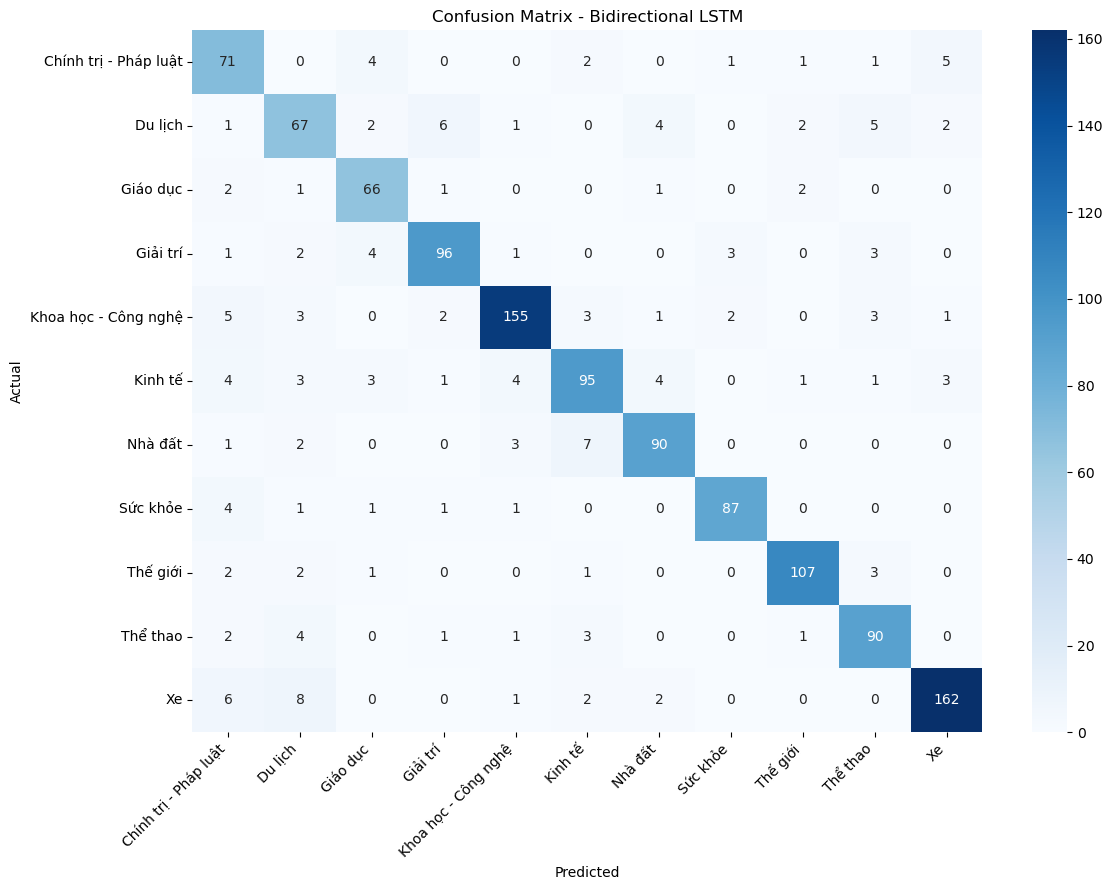

In [15]:
# =========================
# 10. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bidirectional LSTM')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

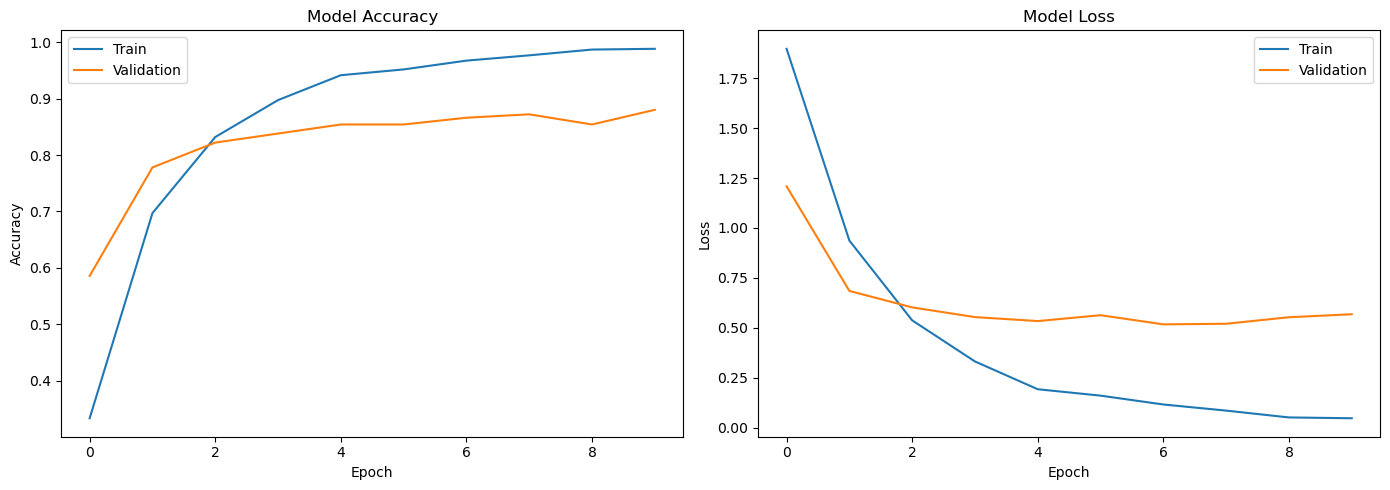

In [16]:
# =========================
# 11. BIỂU ĐỒ ACCURACY & LOSS
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# =========================
# 12. PROBABILITIES (giống PhoBERT)
# =========================
def predict_with_probs(text, threshold=0.3):
    """
    Dự đoán nhãn và hiển thị xác suất từng nhãn
    (tương tự phần PROBABILITIES trong PhoBERT)
    """
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    probs = model.predict(padded, verbose=0)[0]

    print('PROBABILITIES:')
    print('-' * 50)
    for label, prob in zip(encoder.classes_, probs):
        flag = ' <-- PREDICTED' if prob == probs.max() else ''
        print(f'{label:<30} | Prob = {prob:.4f}{flag}')

    predicted_label = encoder.classes_[probs.argmax()]
    print()
    print(f'=> Kết quả dự đoán: {predicted_label} (confidence: {probs.max():.4f})')


# Thử với 1 bài báo mẫu
sample_text = df['text'].iloc[0]
predict_with_probs(sample_text)

PROBABILITIES:
--------------------------------------------------
Chính trị - Pháp luật          | Prob = 0.0001
Du lịch                        | Prob = 0.0000
Giáo dục                       | Prob = 0.0000
Giải trí                       | Prob = 0.0000
Khoa học - Công nghệ           | Prob = 0.0007
Kinh tế                        | Prob = 0.9979 <-- PREDICTED
Nhà đất                        | Prob = 0.0013
Sức khỏe                       | Prob = 0.0000
Thế giới                       | Prob = 0.0000
Thể thao                       | Prob = 0.0000
Xe                             | Prob = 0.0000

=> Kết quả dự đoán: Kinh tế (confidence: 0.9979)
